# Phase 1: Data Cleaning and Preprocessing
In this stage, we focus on preparing the raw global temperature data for analysis. This involves:
* Loading the dataset and assessing its structure.
* Identifying and handling missing (null) values.
* Converting data types (dates and coordinates) into formats suitable for machine learning.

### Step 1: Data Loading and Initial Inspection
We begin by loading the `GlobalLandTemperaturesByMajorCity.csv` file. This step is crucial to understand the scale of our data and identifying how many missing values we need to address.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
file_path = '../01_Data/01_GlobalLandTemperaturesByMajorCity.csv'
df = pd.read_csv(file_path)

# 1. Check total number of rows and columns
rows, columns = df.shape
print(f"Total Rows: {rows}")
print(f"Total Columns: {columns}")

# 2. Check null values per column
print("\nNull values per column:")
print(df.isnull().sum())

# 3. Check total number of rows that have at least one empty or null value
rows_with_nulls = df.isnull().any(axis=1).sum()
print(f"\nTotal rows with at least one null value: {rows_with_nulls}")


Total Rows: 239177
Total Columns: 7

Null values per column:
dt                                   0
AverageTemperature               11002
AverageTemperatureUncertainty    11002
City                                 0
Country                              0
Latitude                             0
Longitude                            0
dtype: int64

Total rows with at least one null value: 11002


### Step 2: Handling Missing Values
The initial inspection showed over 11,000 missing values in the temperature columns. We handle these by:
1. Calculating the **Mean** for `AverageTemperature` and `AverageTemperatureUncertainty`.
2. Filling the null entries with these mean values to ensure no data is lost for our future model.

In [2]:
# Calculate the mean for columns with missing values
avg_temp_mean = df['AverageTemperature'].mean()
avg_temp_uncert_mean = df['AverageTemperatureUncertainty'].mean()

# Fill missing values with the means
df['AverageTemperature'] = df['AverageTemperature'].fillna(avg_temp_mean)
df['AverageTemperatureUncertainty'] = df['AverageTemperatureUncertainty'].fillna(avg_temp_uncert_mean)

# Verify that there are no remaining null values
print(f"Remaining null values: {df.isnull().sum().sum()}")
print('Missing values Handled successfully.')


Remaining null values: 0
Missing values Handled successfully.


### Step 3: Feature Extraction from Dates
The `dt` column is currently a string. We convert it to a **datetime object** and extract the **Year** and **Month** as separate numerical features. This allows our model to understand seasonal and yearly trends.

In [3]:
# 2. Process Dates
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month
print('Date issue Handled successfully.')

Date issue Handled successfully.


### Step 4: Converting Coordinates to Numerical Data
Latitude and Longitude are formatted as strings (e.g., "34.92N"). To use these in a machine learning model, we convert them to floats where:
* **North (N)** and **East (E)** are positive.
* **South (S)** and **West (W)** are negative.

In [4]:

# 3. Convert Coordinates to Numbers 
def convert_coord(coord):
        val = float(coord[:-1])
        direction = coord[-1]
        return -val if direction in ['S', 'W'] else val

df['Lat_Num'] = df['Latitude'].apply(convert_coord)
df['Lon_Num'] = df['Longitude'].apply(convert_coord)
print('String to numeric conversion done successfully.')

String to numeric conversion done successfully.


### Step 5: Visualizing Outliers
Finally, we use a **Boxplot** to visualize the distribution of `AverageTemperature`. This helps us identify if there are any extreme values that might skew our model's predictions.

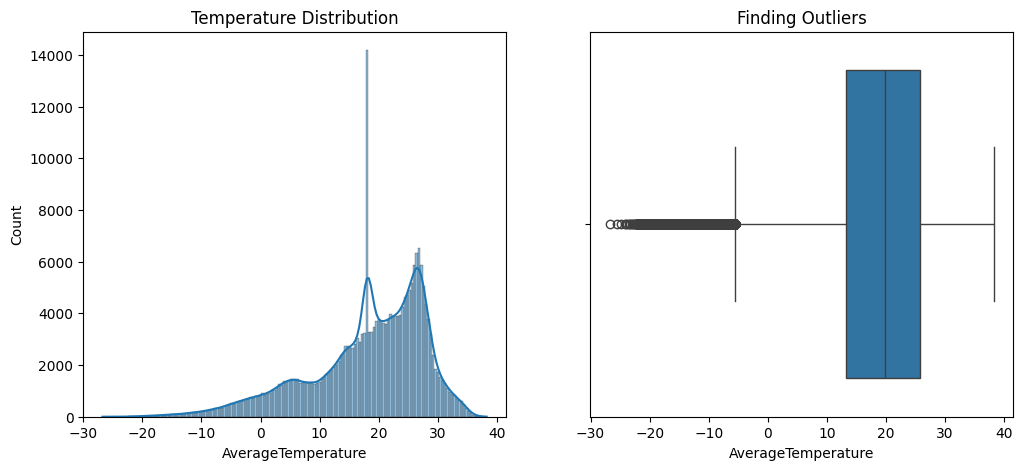

In [5]:
# visualization
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['AverageTemperature'], kde=True)
plt.title('Temperature Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['AverageTemperature'])
plt.title('Finding Outliers')
plt.show()

### Step 6: Removing Outliers
Finally, we remove outliers in `AverageTemperature`. This helps us remove   extreme values that might skew our model's predictions.

In [6]:
# 1. Calculate IQR for AverageTemperature
Q1 = df['AverageTemperature'].quantile(0.25)
Q3 = df['AverageTemperature'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Filter out the outliers
df = df[(df['AverageTemperature'] >= lower_bound) & (df['AverageTemperature'] <= upper_bound)]

print(f"Outliers removed. New dataset size: {len(df)} rows.")

Outliers removed. New dataset size: 233218 rows.


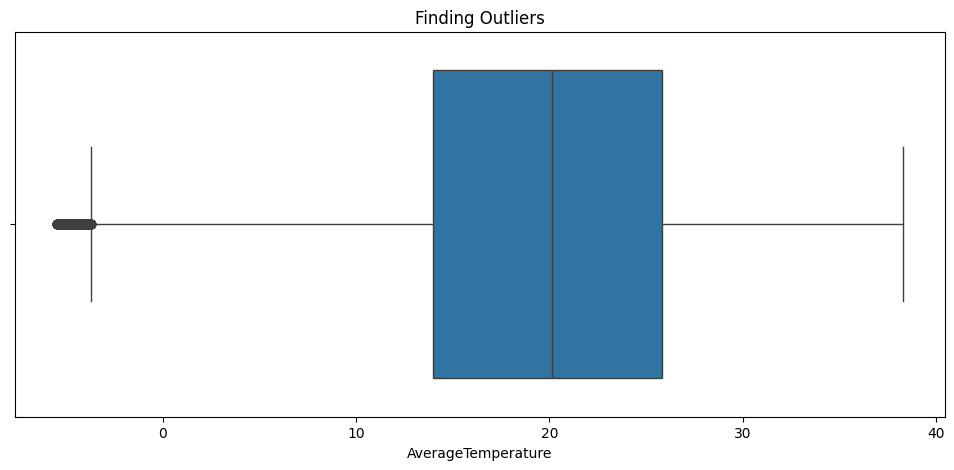

In [7]:
# visualization
plt.figure(figsize=(12, 5))
sns.boxplot(x=df['AverageTemperature'])
plt.title('Finding Outliers')
plt.show()

### Step 7: saving files
Finally, we save our updated file.

In [8]:
# Save the cleaned data to a new CSV file
df.to_csv('../01_Data/02_GlobalLandTemperatures_Cleaned.csv', index=False)
print('Updated file saved successfully.')

Updated file saved successfully.
